<a href="https://colab.research.google.com/github/wojteks456/PMN-26L-119111/blob/main/projekt/projekt_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✓ Importy załadowane pomyślnie

1. WCZYTANIE DANYCH Z OPENML
Pobieranie danych z OpenML (to potrwa kilkanaście sekund)...

Kształt zbioru danych: (284807, 30)

2. ANALIZA DANYCH

--- DYSTRYBUCJA KLAS ---
Transakcje legalne:  284,315 (99.827%)
Transakcje fraudowe: 492 (0.173%)


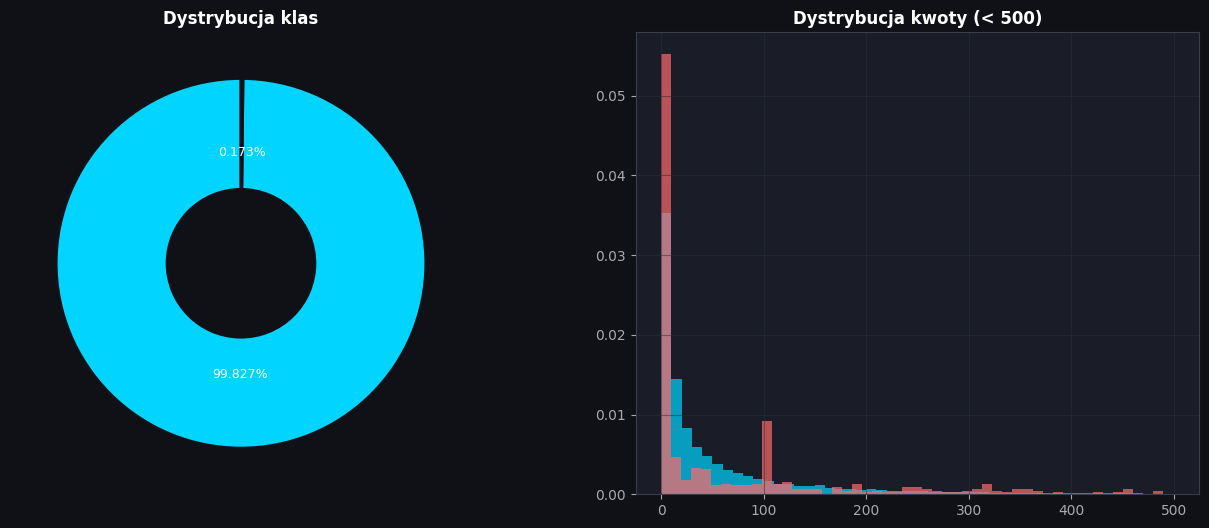


3. PREPROCESSING DANYCH

Balansowanie SMOTE...

4. TRENOWANIE MODELI
[1/4] Logistic Regression...
[2/4] Random Forest...
[3/4] XGBoost GPU...
[4/4] TensorFlow DNN...


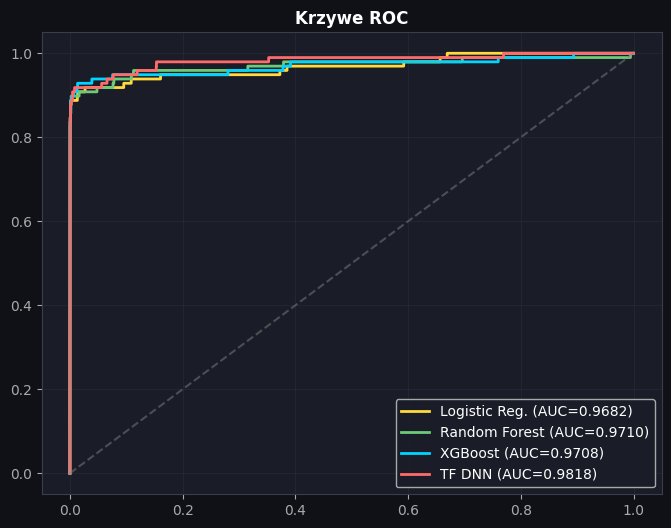


GOTOWE!


In [13]:
# ============================================================
# 0. IMPORTY
# ============================================================
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, f1_score)
from imblearn.over_sampling import SMOTE

import xgboost as xgb
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Style
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#3a3d4d',
    'axes.labelcolor':  '#e0e0e0',
    'text.color':       '#e0e0e0',
    'xtick.color':      '#aaaaaa',
    'ytick.color':      '#aaaaaa',
    'grid.color':       '#2a2d3d',
    'grid.alpha':       0.5,
    'axes.grid':        True,
})
PALETTE = ['#00d4ff', '#ff6b6b', '#ffd93d', '#6bcb77', '#845ec2']
OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("✓ Importy załadowane pomyślnie")

# ============================================================
# 1. WCZYTANIE DANYCH (OPENML)
# ============================================================
print("\n" + "="*60)
print("1. WCZYTANIE DANYCH Z OPENML")
print("="*60)

from sklearn.datasets import fetch_openml
print("Pobieranie danych z OpenML (to potrwa kilkanaście sekund)...")
dataset = fetch_openml(name='creditcard', version=1, as_frame=True, parser='auto')
df = dataset.frame
df['Class'] = pd.to_numeric(df['Class'])

print(f"\nKształt zbioru danych: {df.shape}")

# ============================================================
# 2. ANALIZA EKSPLORACYJNA (EDA)
# ============================================================
print("\n" + "="*60)
print("2. ANALIZA DANYCH")
print("="*60)

fraud_count = df['Class'].sum()
legit_count = len(df) - fraud_count
fraud_pct = fraud_count / len(df) * 100
print(f"\n--- DYSTRYBUCJA KLAS ---")
print(f"Transakcje legalne:  {legit_count:,} ({100-fraud_pct:.3f}%)")
print(f"Transakcje fraudowe: {fraud_count:,} ({fraud_pct:.3f}%)")

fig = plt.figure(figsize=(16, 6), facecolor='#0f1117')
gs = gridspec.GridSpec(1, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
sizes = [legit_count, fraud_count]
wedges, texts, autotexts = ax1.pie(sizes, colors=[PALETTE[0], PALETTE[1]],
    autopct='%1.3f%%', startangle=90, wedgeprops=dict(width=0.6, edgecolor='#0f1117', linewidth=2))
for at in autotexts: at.set_fontsize(9); at.set_color('white')
ax1.set_title('Dystrybucja klas', color='white', fontweight='bold')

# Poprawiony histogram - używamy Amount zamiast brakującego Time
ax2 = fig.add_subplot(gs[0, 1])
for cls, color in zip([0,1], [PALETTE[0], PALETTE[1]]):
    data = df[df['Class']==cls]['Amount']
    ax2.hist(data[data < 500], bins=50, color=color, alpha=0.7, density=True)
ax2.set_title('Dystrybucja kwoty (< 500)', color='white', fontweight='bold')

plt.savefig(f'{OUTPUT_DIR}/01_eda_analysis.png', dpi=120, bbox_inches='tight', facecolor='#0f1117')
plt.show()

# ============================================================
# 3. PREPROCESSING
# ============================================================
print("\n" + "="*60)
print("3. PREPROCESSING DANYCH")
print("="*60)

scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])

# Pobieramy kolumny (bez Time)
feature_cols = [f'V{i}' for i in range(1, 29)] + ['Amount_scaled']

X = df[feature_cols].values.astype('float32')
y = df['Class'].values.astype('int8')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\nBalansowanie SMOTE...")
del df
gc.collect()

smote = SMOTE(sampling_strategy=0.3, random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# ============================================================
# 4. TRENOWANIE MODELI
# ============================================================
print("\n" + "="*60)
print("4. TRENOWANIE MODELI")
print("="*60)

results = {}

print("[1/4] Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42, C=0.1)
lr.fit(X_train_sm, y_train_sm)
y_proba_lr = lr.predict_proba(X_test)[:, 1]
results['Logistic Reg.'] = {'y_pred': lr.predict(X_test), 'y_proba': y_proba_lr,
                            'roc_auc': roc_auc_score(y_test, y_proba_lr), 'pr_auc': average_precision_score(y_test, y_proba_lr)}

print("[2/4] Random Forest...")
rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1, class_weight='balanced')
rf.fit(X_train, y_train)
y_proba_rf = rf.predict_proba(X_test)[:, 1]
results['Random Forest'] = {'y_pred': rf.predict(X_test), 'y_proba': y_proba_rf,
                            'roc_auc': roc_auc_score(y_test, y_proba_rf), 'pr_auc': average_precision_score(y_test, y_proba_rf)}

print("[3/4] XGBoost GPU...")
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.05,
    scale_pos_weight=scale_pos, eval_metric='aucpr', random_state=42,
    verbosity=0, device='cuda'
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
results['XGBoost'] = {'y_pred': xgb_model.predict(X_test), 'y_proba': y_proba_xgb,
                      'roc_auc': roc_auc_score(y_test, y_proba_xgb), 'pr_auc': average_precision_score(y_test, y_proba_xgb)}

print("[4/4] TensorFlow DNN...")
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'), layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid'),
])
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['AUC'])
early_stop = keras.callbacks.EarlyStopping(monitor='val_auc', patience=3, restore_best_weights=True, mode='max')
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=2048,
          class_weight={0: 1, 1: int(scale_pos)}, callbacks=[early_stop], verbose=0)
y_proba_dnn = model.predict(X_test, verbose=0).flatten()
results['TF DNN'] = {'y_pred': (y_proba_dnn >= 0.5).astype(int), 'y_proba': y_proba_dnn,
                     'roc_auc': roc_auc_score(y_test, y_proba_dnn), 'pr_auc': average_precision_score(y_test, y_proba_dnn)}

# ============================================================
# WYNIKI
# ============================================================
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 6), facecolor='#0f1117')
colors_m = [PALETTE[2], PALETTE[3], PALETTE[0], PALETTE[1]]
for (name, res), color in zip(results.items(), colors_m):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC={res['roc_auc']:.4f})")
ax.plot([0,1],[0,1],'--', color='gray', alpha=0.5)
ax.set_title('Krzywe ROC', color='white', fontweight='bold')
ax.legend(facecolor='#1a1d27', labelcolor='white')
plt.savefig(f'{OUTPUT_DIR}/02_roc_curves.png', dpi=120, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print("\nGOTOWE!")